# Modelo 1: Regresión Lineal

**Tipo:** Regresión — predice un valor numérico continuo.

**Objetivo:** Predecir el radio del planeta (`radio`) a partir de la masa (`masa`).

**Métrica principal:** R² Score.

---

## Justificación técnica

Se eligió la Regresión Lineal como primer modelo porque cumple el rol de **baseline de regresión**: establece cuánto de la variación del radio puede explicarse con una relación lineal simple respecto a la masa. Si el R² es bajo, confirma que la relación masa → radio no es lineal, lo cual motiva el uso de modelos más complejos.

**Ventajas:**
- Altamente interpretable: el coeficiente de la masa indica cuánto aumenta el radio por cada unidad de masa.
- Rápido de entrenar y sin hiperparámetros relevantes.
- Útil como diagnóstico antes de aplicar modelos no lineales.

**Limitaciones:**
- Asume linealidad: los gigantes gaseosos saturan en radio aunque la masa siga aumentando, lo que viola este supuesto.
- No sirve para clasificar tipos de planeta, solo para predecir valores numéricos continuos.
- Sensible a outliers en masa y radio.

**Resultado esperado:** R² bajo (~0.02), lo que confirma que la relación masa-radio no es lineal y justifica el uso de árboles de decisión para clasificación.

In [1]:
# ============================================================
# Preparación de datos para los modelos
# ============================================================
import numpy as np
import pandas as pd

# Datos originales sin imputar
df_raw = pd.read_csv('Datos/planets.csv')

# Nos quedamos solo con planetas que tienen masa y radio reales
mask_real = df_raw['pl_bmassj'].notna() & df_raw['pl_radj'].notna()
df_work = df_raw.loc[mask_real, ['pl_hostname', 'pl_letter', 'pl_bmassj', 'pl_radj']].copy()
df_work.rename(columns={'pl_bmassj': 'masa', 'pl_radj': 'radio'}, inplace=True)

# Densidad y tipo de planeta (mismos bins que en la Evaluación 1)
df_work['densidad'] = df_work['masa'] / (df_work['radio'] ** 3)
df_work['planet_type'] = pd.cut(
    df_work['densidad'],
    bins=[0, 0.1, 0.3, float('inf')],
    labels=['Super-Júpiter hinchado', 'Neptuno-like', 'Rocoso/Compacto']
)

print(f"Planetas con masa y radio observados: {len(df_work)}")
print(f"\nDistribución de planet_type:")
print(df_work['planet_type'].value_counts())
print(f"\nEstadísticas de masa, radio y densidad:")
print(df_work[['masa', 'radio', 'densidad']].describe().round(3))
df_work.head()


Planetas con masa y radio observados: 509

Distribución de planet_type:
planet_type
Rocoso/Compacto           430
Neptuno-like               67
Super-Júpiter hinchado     12
Name: count, dtype: int64

Estadísticas de masa, radio y densidad:
          masa    radio  densidad
count  509.000  509.000   509.000
mean     1.807    0.842    41.649
std      3.788    0.526   240.564
min      0.000    0.042     0.004
25%      0.069    0.269     0.413
50%      0.615    1.005     1.008
75%      1.490    1.250     4.147
max     28.000    3.000  2644.524


,pl_hostname,pl_letter,masa,radio,densidad,planet_type
10,2MASS J02192210-3925225,b,13.90000,1.440,4.655082,Rocoso/Compacto
14,2MASS J21402931+1625183 A,b,20.95000,0.920,26.904229,Rocoso/Compacto
26,55 Cnc,e,0.02542,0.170,5.174028,Rocoso/Compacto
46,BD+20 594,b,0.05129,0.199,6.508389,Rocoso/Compacto
59,CT Cha,b,17.00000,2.200,1.596544,Rocoso/Compacto


## Modelo 1: Regresión Lineal (REGRESIÓN)
**Tipo:** Regresión — predice un valor numérico continuo.

**Objetivo:** Predecir el **radio del planeta (`radio`)** a partir de la **masa (`masa`)** — es el análogo astronómico al "predecir largo del pétalo a partir del sépalo" de Actividad1.

**Métrica:** R² Score — qué porcentaje de la variación del radio es explicada por la masa.


In [2]:
# ============= Regresión Lineal =============
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

df_binary = df_work[['masa', 'radio']].copy()
df_binary.head()


,masa,radio
10,13.90000,1.440
14,20.95000,0.920
26,0.02542,0.170
46,0.05129,0.199
59,17.00000,2.200


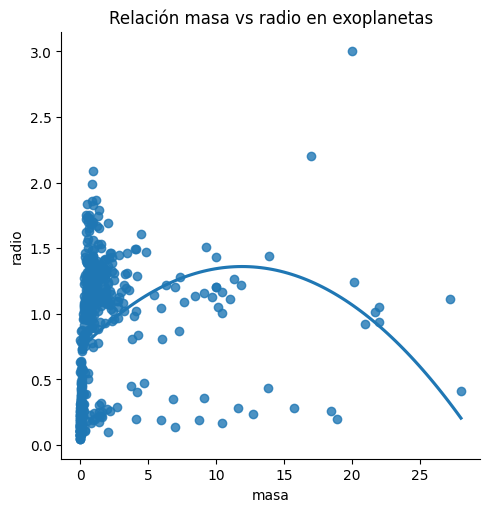

In [3]:
# Scatter inicial para ver la relación
sns.lmplot(x='masa', y='radio', data=df_binary, order=2, ci=None)
plt.title('Relación masa vs radio en exoplanetas')
plt.show()

In [4]:
# Limpieza de NaN por si quedaran
df_binary = df_binary.dropna().copy()

X = np.array(df_binary['masa']).reshape(-1, 1)
y = np.array(df_binary['radio']).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

regr = LinearRegression()
regr.fit(X_train, y_train)
print(f'Regresión Lineal R²: {regr.score(X_test, y_test):.4f}')

Regresión Lineal R²: 0.0171


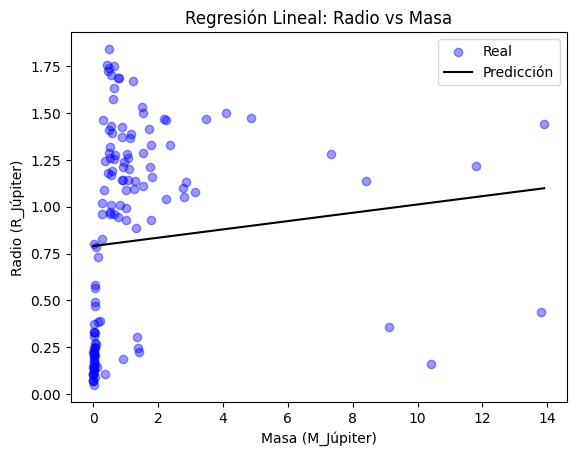

In [5]:
y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='b', alpha=0.4, label='Real')
plt.plot(np.sort(X_test, axis=0), regr.predict(np.sort(X_test, axis=0)),
        color='k', label='Predicción')
plt.xlabel('Masa (M_Júpiter)')
plt.ylabel('Radio (R_Júpiter)')
plt.title('Regresión Lineal: Radio vs Masa')
plt.legend()
plt.show()